<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment4/Assignment%204%3A%20The%20Predictive%20Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install -q missingno category_encoders

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import category_encoders as ce

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

print("All libraries loaded successfully")

All libraries loaded successfully


In [26]:
FILEPATH_vital = "https://raw.githubusercontent.com/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Assignment4/OmniCare_Clinical_Vitals.csv"
FILEPATH_telemetry = "https://raw.githubusercontent.com/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Assignment4/OmniCare_Telemetry_Data.csv"

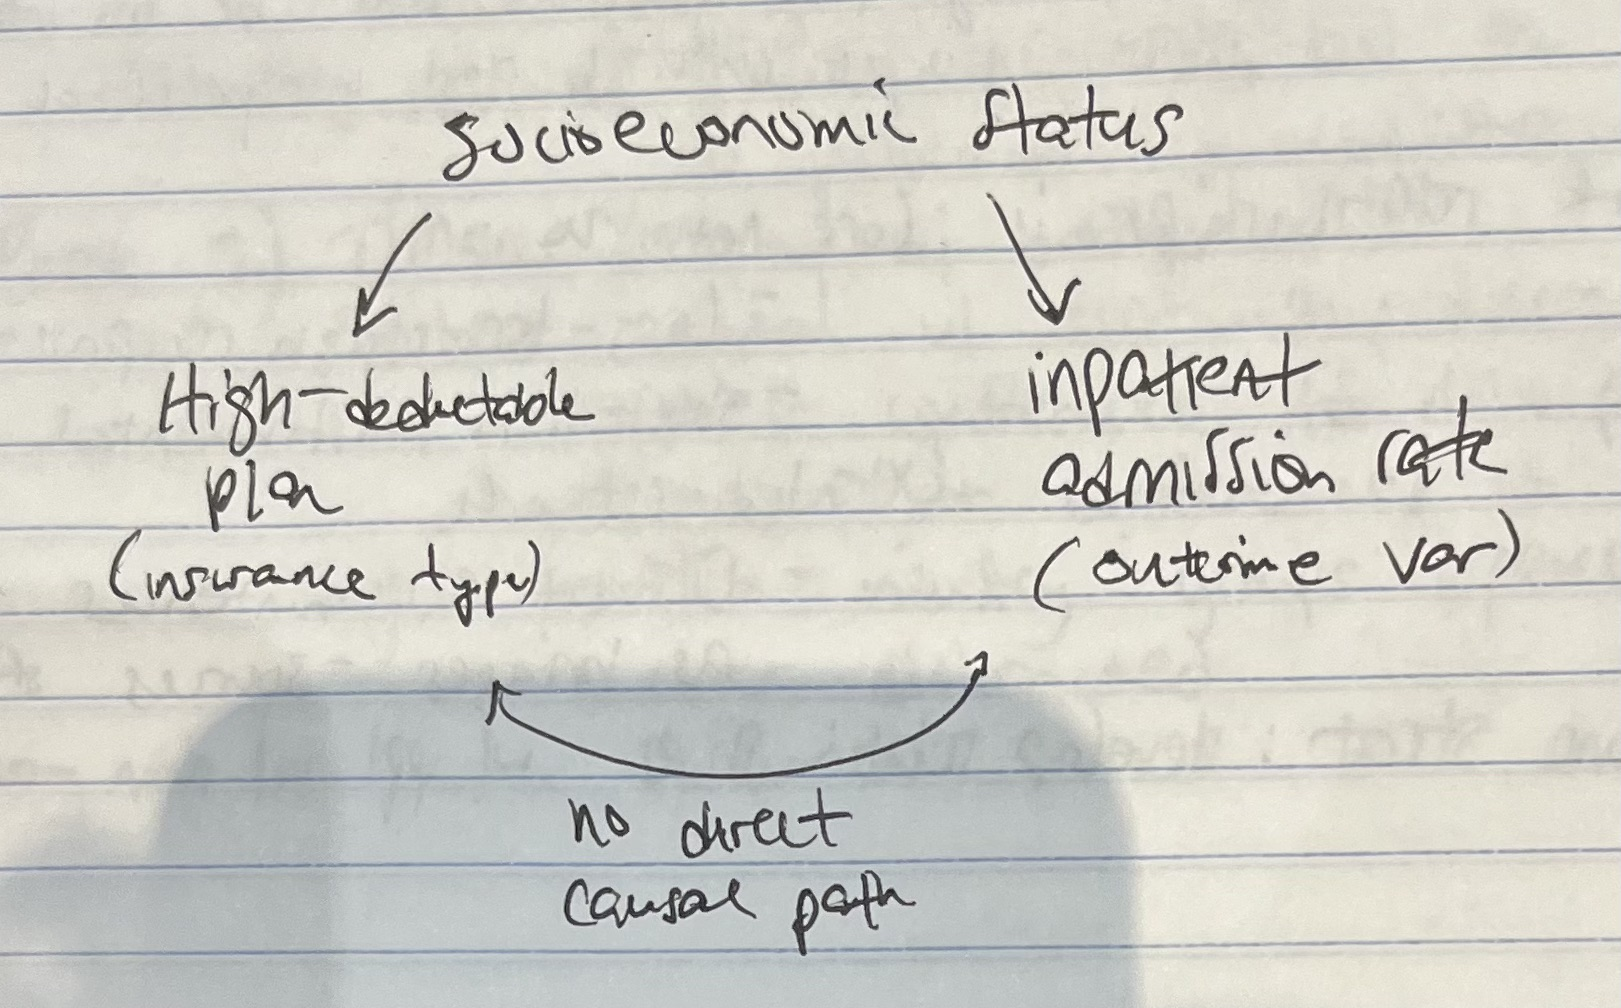

Socioeconomic status is the confounder. There is no direct causal path between high deductable plans and inpatient admission rate, which is the outcome variable.

In [27]:
# 1.2: VIF Audit
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vital = pd.read_csv(FILEPATH_vital)

features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = df_vital[features].dropna()

# calculate the vif
vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF":     [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("Initial VIF Matrix:")
print(vif.to_string(index=False))

# find if the threshold is greater than 10
critical = vif[vif["VIF"] > 10]["Feature"].tolist()
print(f"\nFeatures exceeding VIF = 10.0: {critical}")

X_reduced = X.drop(columns=["BMI"])

vif_reduced = pd.DataFrame({
    "Feature": X_reduced.columns,
    "VIF":     [variance_inflation_factor(X_reduced.values, i)
                for i in range(X_reduced.shape[1])]
})
print("\nRecalculated VIF Matrix (after dropping BMI):")
print(vif_reduced.to_string(index=False))

Initial VIF Matrix:
     Feature      VIF
   Weight_kg  61.6047
   Height_cm 131.1758
         BMI  77.1010
 Systolic_BP 274.8856
Diastolic_BP 269.8932

Features exceeding VIF = 10.0: ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']

Recalculated VIF Matrix (after dropping BMI):
     Feature      VIF
   Weight_kg  39.9776
   Height_cm 130.8793
 Systolic_BP 270.5292
Diastolic_BP 267.5811


All of the features in the initial model are severely multicollinear. Every single VIF is higher than the critical threshold of 10, meaning each feature can be almost entirely predicted by the others, which inflates OLS coefficient variance. This tells us that removing BMI alone is insufficient and that a further fix is needed. Most likely, dropping either Systolic_BP or Diastolic_BP and addressing the weight/height collinearity.

Missing value counts:
Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Continuous_Heart_Rate             1214
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
Primary_Diagnosis_Code_Encoded       0
dtype: int64

Missing value percentages:
Patient_ID                        0.0000
High_Deductible_Insurance_Plan    0.0000
Inpatient_Admission_Rate          0.0000
Continuous_Heart_Rate            24.2800
Primary_Diagnosis_Code            0.0000
Clinic_Capacity_Percentage        0.0000
Time_of_Day_Index                 0.0000
Procedure_Cost_USD                0.0000
Primary_Diagnosis_Code_Encoded    0.0000
dtype: float64


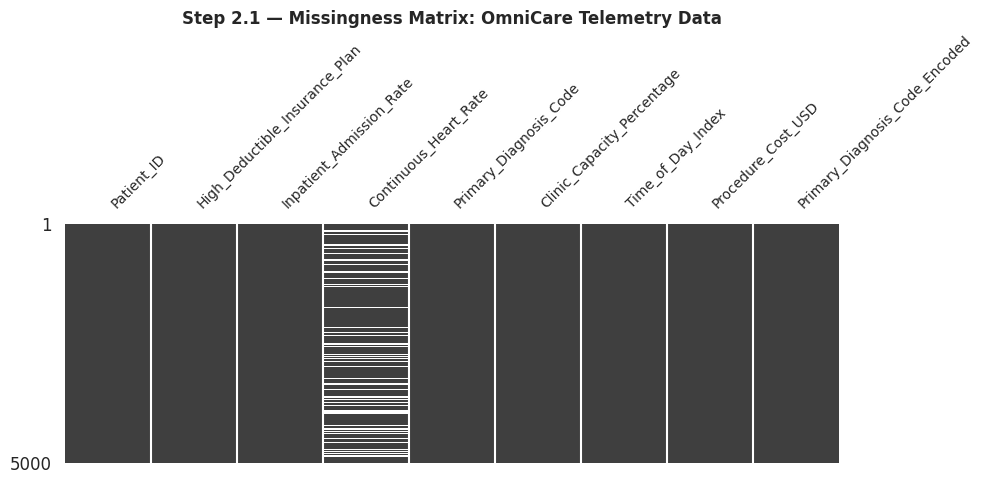

Figure saved: step2_1_missingness_matrix.png


In [28]:
# 2.1
df_telemetry = pd.read_csv(FILEPATH_telemetry)

print("Missing value counts:")
print(df.isnull().sum())
print("\nMissing value percentages:")
print((df.isnull().sum() / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
msno.matrix(df, ax=ax, sparkline=False, fontsize=10)
ax.set_title("Step 2.1 — Missingness Matrix: OmniCare Telemetry Data",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("step2_1_missingness_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: step2_1_missingness_matrix.png")

Every column is solid dark bars with no white gaps, except for Continuous_Heart_Rate, which shows heavy white striping concentrated in the lower portion of the matrix. This isn't random scatter, the missing values appear in dense bands rather than small individual gaps. This looks like MNAR.

In [29]:
print(f"Distinct ICD-10 codes: {df_telemetry['Primary_Diagnosis_Code'].nunique()}")

encoder  = ce.BinaryEncoder(cols=["Primary_Diagnosis_Code"])
X_binary = encoder.fit_transform(df_telemetry[["Primary_Diagnosis_Code"]])

print(f"\nBinaryEncoder columns: {X_binary.shape[1]}  (vs 850 with get_dummies)")
print("No dummy trap, no dimensionality explosion.")

Distinct ICD-10 codes: 847

BinaryEncoder columns: 10  (vs 850 with get_dummies)
No dummy trap, no dimensionality explosion.


In [30]:
# 2.3: Target Encoding Implementation
import category_encoders as ce

encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

df_telemetry["Primary_Diagnosis_Code_Encoded"] = encoder.fit_transform(
    df_telemetry["Primary_Diagnosis_Code"], df["Procedure_Cost_USD"]
)

print(df_telemetry[["Primary_Diagnosis_Code", "Primary_Diagnosis_Code_Encoded"]].head())

  Primary_Diagnosis_Code  Primary_Diagnosis_Code_Encoded
0                J86.381                       1707.6971
1                M29.789                       1792.3032
2                E49.618                       1730.3350
3                E66.244                       1725.0609
4                J45.553                       1801.8211


In [31]:
# 3.1

# ── 1. Merge sanitized features into one dataframe ────────────────────────────
# vitals (Phase 1): BMI dropped, leaving Weight_kg, Height_cm, Systolic_BP, Diastolic_BP
# telemetry: target-encoded diagnosis + remaining features
final_df = df_telemetry.merge(df_vital, on="Patient_ID").dropna()

# ── 2. Define formula and fit OLS ─────────────────────────────────────────────
formula = ("Procedure_Cost_USD ~ Primary_Diagnosis_Code_Encoded + "
           "Clinic_Capacity_Percentage + Time_of_Day_Index + "
           "Weight_kg + Height_cm + Systolic_BP + Diastolic_BP")

model = smf.ols(formula=formula, data=final_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     183.9
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          3.87e-235
Time:                        23:26:10   Log-Likelihood:                -27366.
No. Observations:                3786   AIC:                         5.475e+04
Df Residuals:                    3778   BIC:                         5.480e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [33]:
rmse_value = rmse(final_df["Procedure_Cost_USD"], model.fittedvalues)

print(f"RMSE: ${rmse_value:,.2f}")

RMSE: $333.34


This means the algorithm's typical pricing error is 27.8% of the procedure cost, so on any given patient, the model's price prediction is off by roughly 1/3 of the bill. This is a little better than the $450 benchmark, but it is still too volatilek for implementation.

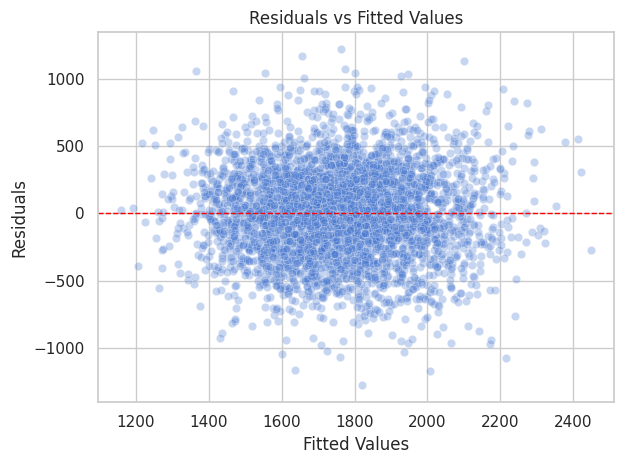

In [34]:
# 3.3:
import seaborn as sns

fitted = model.fittedvalues
residuals = model.resid

sns.scatterplot(x=fitted, y=residuals, alpha=0.3)
plt.axhline(0, color="red", linewidth=1, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

P — Persona
You are a senior econometrician and Python engineer specializing in healthcare analytics and OLS regression diagnostics.

R — Role
Your role is to write a Python script that executes White's Lagrange Multiplier Test for Heteroscedasticity on a pre-fitted statsmodels OLS regression object.

I — Instructions
Using statsmodels.stats.diagnostic.het_white function, run White's LM test on the residuals and fitted model matrix from an existing OLS model object named model, fitted on a dataframe named final_df. Extract and print the LM statistic, the LM p-value, the F-statistic, and the F p-value. Then print a single concluding sentence stating whether the null hypothesis of homoscedasticity is rejected at the 0.05 significance level based on the LM p-value.

M — Meaning
This test is a critical regulatory checkpoint before deploying a dynamic medical pricing API across New England hospital networks. A rejected null means the OLS standard errors are invalid, the pricing algorithm is statistically unsafe for live deployment, and the model requires heteroscedasticity-robust correction before any executive sign-off.

E — Evaluation
The output is correct if: (1) it uses het_white from statsmodels.stats.diagnostic, (2) it references the existing model object without re-fitting, (3) it prints all four test statistics cleanly labeled, and (4) it ends with an unambiguous plain-English conclusion about the null hypothesis at α = 0.05.

In [36]:
# 4.1:
from statsmodels.stats.diagnostic import het_white

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

print(f"LM Statistic : {lm_stat:.4f}")
print(f"LM p-value   : {lm_pvalue:.4f}")
print(f"F Statistic  : {f_stat:.4f}")
print(f"F p-value    : {f_pvalue:.4f}")

if lm_pvalue < 0.05:
    print("\nConclusion: The null hypothesis of homoscedasticity is rejected "
          f"(LM p = {lm_pvalue:.4f} < 0.05) — heteroscedasticity is present "
          "and OLS standard errors are unreliable.")
else:
    print("\nConclusion: The null hypothesis of homoscedasticity cannot be rejected "
          f"(LM p = {lm_pvalue:.4f} > 0.05) — the constant variance assumption holds.")

LM Statistic : 159.2136
LM p-value   : 0.0000
F Statistic  : 4.7035
F p-value    : 0.0000

Conclusion: The null hypothesis of homoscedasticity is rejected (LM p = 0.0000 < 0.05) — heteroscedasticity is present and OLS standard errors are unreliable.
